# RAIDS-NIDS Jupyter starter

In [ ]:

from pathlib import Path
import os
import sys

PROJECT = Path(r"C:\Users\ASUS\raids-nids")

assert (PROJECT / "pyproject.toml").exists(), "pyproject.toml not found"
assert (PROJECT / "src" / "raids_nids").exists(), "Package source not found"

os.chdir(PROJECT)
sys.path.insert(0, str(PROJECT / "src"))

print("Project:", PROJECT)
print("Package source:", PROJECT / "src" / "raids_nids")

Project: C:\Users\ASUS\raids-nids
Package source: C:\Users\ASUS\raids-nids\src\raids_nids


In [2]:
# %pip install -e ".[dev]"

Obtaining file:///C:/Users/ASUS/raids-nids
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for raids-nids (pyproject.toml): started
  Building editable for raids-nids (pyproject.toml): finished with status 'done'
  Created wheel for raids-nids: filename=raids_nids-0.1.1-0.editable-py3-none-any.whl size=3506 sha256=0c77493ced51c0a6a0834acdbcfb556479633a7072a950b8fb9f89fd8e2fdfa8
  Stored in directory: C:\Users\ASUS\AppData\Local\Temp\pip-ephem-wheel-cache-0j9jisdj\wheels\60\06\8b\f47b93d709e2c34b3e618d4f0acd90b3f6c5c8169b11c95d

## Generate engineering-only synthetic data

In [ ]:
from raids_nids.synthetic import generate_synthetic

source_path, target_path = generate_synthetic(
    PROJECT / "data" / "synthetic",
    seed=11
)

print("Created:", source_path)
print("Created:", target_path)

Created: C:\Users\ASUS\raids-nids\data\synthetic\source.csv
Created: C:\Users\ASUS\raids-nids\data\synthetic\target.csv


## Audit both datasets

In [4]:
from raids_nids.audit import audit_dataset
from IPython.display import display
import pandas as pd

source_audit = audit_dataset(
    PROJECT / "configs" / "datasets" / "synthetic_source.yaml",
    PROJECT / "results" / "audits" / "Synthetic-Source-Smoke.json",
)
target_audit = audit_dataset(
    PROJECT / "configs" / "datasets" / "synthetic_target.yaml",
    PROJECT / "results" / "audits" / "Synthetic-Target-Smoke.json",
)
display(pd.DataFrame([source_audit, target_audit])[
    ["dataset", "rows_audited", "usable_features", "exact_duplicate_rows"]
] )

,dataset,rows_audited,usable_features,exact_duplicate_rows
0,Synthetic-Source-Smoke,3000,20,0
1,Synthetic-Target-Smoke,4000,20,0


## Run static and adaptive experiments

Each run writes its configuration, summary, window trace, environment and trained model under `results/runs`.

In [5]:
from pathlib import Path
import importlib
import sys

runner_file = PROJECT / "src" / "raids_nids" / "runner.py"
text = runner_file.read_text(encoding="utf-8")

text = text.replace(
    "import resource\n",
    """try:
    import resource
except ImportError:
    resource = None
"""
)

text = text.replace(
    '"peak_process_memory_mb": resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024.0,',
    '"peak_process_memory_mb": '
    '(resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024.0 '
    'if resource is not None else None),'
)

runner_file.write_text(text, encoding="utf-8")

sys.modules.pop("raids_nids.runner", None)
importlib.invalidate_caches()

print("Windows compatibility fix applied:", runner_file)

Windows compatibility fix applied: C:\Users\ASUS\raids-nids\src\raids_nids\runner.py


In [6]:
from pathlib import Path
import importlib
import sys

runner_file = PROJECT / "src" / "raids_nids" / "runner.py"
text = runner_file.read_text(encoding="utf-8")

# Clean anything inserted between the standard imports.
start = text.index("import re") + len("import re")
end = text.index("import sys", start)
text = text[:start] + "\n" + text[end:]

# Reconstruct the cross-platform resource import.
sklearn_marker = (
    "from sklearn.model_selection import "
    "StratifiedGroupKFold, train_test_split"
)
package_marker = "from .adaptation import select_queries"

start = text.index(sklearn_marker) + len(sklearn_marker)
end = text.index(package_marker, start)

resource_block = """

try:
    import resource
except ImportError:  # resource is unavailable on Windows.
    resource = None

"""

text = text[:start] + resource_block + text[end:]

# Verify syntax before replacing the file.
compile(text, str(runner_file), "exec")
runner_file.write_text(text, encoding="utf-8")

sys.modules.pop("raids_nids.runner", None)
importlib.invalidate_caches()

print("runner.py repaired successfully")

runner.py repaired successfully


In [7]:
from raids_nids.runner import run_experiment

print("Import successful")

Import successful


In [8]:
from raids_nids.runner import run_experiment
import pandas as pd
from IPython.display import display

static_summary = run_experiment(
    PROJECT / "configs" / "experiments" / "smoke_static.yaml"
)

adaptive_summary = run_experiment(
    PROJECT / "configs" / "experiments" / "smoke_adaptive.yaml"
)

display(pd.DataFrame([static_summary, adaptive_summary])[
    [
        "method",
        "labels_queried",
        "label_budget_ceiling",
        "mean_known_macro_f1",
        "mean_novel_auprc",
        "primary_normalized_recovery_area",
    ]
])

,method,labels_queried,label_budget_ceiling,mean_known_macro_f1,mean_novel_auprc,primary_normalized_recovery_area
0,logistic_open_set,0,0,0.967887,0.986526,1.000000
1,adaptive_prototype_1pct,35,40,0.946437,0.455887,0.986206


## Aggregate completed runs

In [9]:
from raids_nids.aggregate import aggregate_results

aggregation = aggregate_results(PROJECT / "results" / "runs", PROJECT / "results" / "aggregate")
print(aggregation)
display(pd.read_csv(PROJECT / "results" / "aggregate" / "method_ranking.csv"))

{'runs': 2, 'methods': 2, 'complete_blocks': 1}


,method,n_runs,mean,std,median,bootstrap_95_low,bootstrap_95_high
0,logistic_open_set,1,1.000000,0.0,1.000000,1.000000,1.000000
1,adaptive_prototype_1pct,1,0.986206,0.0,0.986206,0.986206,0.986206


## Check integrity tests

In [10]:
import subprocess

subprocess.run([sys.executable, "-m", "pytest", "-q"], cwd=PROJECT, check=True)

CompletedProcess(args=['C:\\Users\\ASUS\\anaconda3\\envs\\raids-nids\\python.exe', '-m', 'pytest', '-q'], returncode=0)

## Next step for real data


In [11]:
RAW = PROJECT / "data" / "raw"
RAW.mkdir(parents=True, exist_ok=True)

print("Place extracted CSV files here:")
print(RAW)

Place extracted CSV files here:
C:\Users\ASUS\raids-nids\data\raw


In [12]:
import pandas as pd

csv_files = list(RAW.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {RAW}")

for file in csv_files:
    preview = pd.read_csv(file, nrows=5, low_memory=False)

    print("\nFILE:", file.name)
    print("SIZE (GB):", round(file.stat().st_size / (1024**3), 3))
    print("NUMBER OF COLUMNS:", len(preview.columns))
    print("COLUMNS:")
    print(preview.columns.tolist())

    for candidate in ["Attack", "Label", "attack", "label"]:
        if candidate in preview.columns:
            print(f"\n{candidate} sample values:")
            print(preview[candidate].tolist())


FILE: NetFlow_v3_Features.csv
SIZE (GB): 0.0
NUMBER OF COLUMNS: 2
COLUMNS:
['Feature', 'Description']

FILE: NF-UNSW-NB15-v3.csv
SIZE (GB): 0.538
NUMBER OF COLUMNS: 55
COLUMNS:
['FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS', 'IPV4_SRC_ADDR', 'L4_SRC_PORT', 'IPV4_DST_ADDR', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS', 'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS', 'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT', 'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES', 'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES', 'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT', 'ICMP_TYPE', 'ICMP_I

In [13]:
from collections import Counter
import numpy as np
import pandas as pd

dataset_file = PROJECT / "data" / "raw" / "NF-UNSW-NB15-v3.csv"

attack_counts = Counter()
binary_counts = Counter()

total_rows = 0
missing_time = 0
time_order_violations = 0
previous_time = None

required_columns = [
    "FLOW_START_MILLISECONDS",
    "FLOW_END_MILLISECONDS",
    "Label",
    "Attack",
]

for chunk in pd.read_csv(
    dataset_file,
    usecols=required_columns,
    chunksize=250_000,
    low_memory=False,
):
    total_rows += len(chunk)

    attack_counts.update(chunk["Attack"].astype(str))
    binary_counts.update(chunk["Label"].astype(str))

    times = pd.to_numeric(
        chunk["FLOW_START_MILLISECONDS"],
        errors="coerce"
    )

    missing_time += int(times.isna().sum())
    valid_times = times.dropna().to_numpy()

    if len(valid_times):
        time_order_violations += int(
            np.count_nonzero(np.diff(valid_times) < 0)
        )

        if previous_time is not None and valid_times[0] < previous_time:
            time_order_violations += 1

        previous_time = valid_times[-1]

print("Total rows:", total_rows)
print("Missing timestamps:", missing_time)
print("Time-order violations:", time_order_violations)

print("\nMulticlass distribution:")
display(
    pd.DataFrame(
        attack_counts.items(),
        columns=["Attack", "Count"]
    ).sort_values("Count", ascending=False)
)

print("\nBinary distribution:")
display(
    pd.DataFrame(
        binary_counts.items(),
        columns=["Label", "Count"]
    ).sort_values("Label")
)

Total rows: 2365424
Missing timestamps: 0
Time-order violations: 335443

Multiclass distribution:


,Attack,Count
0,Benign,2237731
2,Exploits,42748
1,Fuzzers,33816
5,Generic,19651
4,Reconnaissance,17074
6,DoS,5980
3,Backdoor,4659
7,Shellcode,2381
8,Analysis,1226
9,Worms,158



Binary distribution:


,Label,Count
0,0,2237731
1,1,127693


In [14]:
import yaml

config = {
    "name": "NF-UNSW-NB15-v3",
    "path": "data/raw/NF-UNSW-NB15-v3.csv",
    "label_column": "Attack",
    "extra_label_columns": ["Label"],
    "time_column": "FLOW_START_MILLISECONDS",
    "drop_columns": [
        "FLOW_END_MILLISECONDS",
        "IPV4_SRC_ADDR",
        "IPV4_DST_ADDR",
    ],
    "auto_drop_identifiers": True,
    "sampling": {
        "max_rows": 500_000,
        "mode": "stratified",
        "seed": 11,
    },
}

config_path = (
    PROJECT
    / "configs"
    / "datasets"
    / "nf_unsw_nb15_v3.yaml"
)

config_path.parent.mkdir(parents=True, exist_ok=True)

with config_path.open("w", encoding="utf-8") as file:
    yaml.safe_dump(config, file, sort_keys=False)

print("Configuration created:", config_path)

Configuration created: C:\Users\ASUS\raids-nids\configs\datasets\nf_unsw_nb15_v3.yaml


In [15]:
from raids_nids.audit import audit_dataset

audit_output = (
    PROJECT
    / "results"
    / "audits"
    / "NF-UNSW-NB15-v3.json"
)

audit_report = audit_dataset(
    config_path,
    audit_output
)

display(pd.DataFrame({
    "Item": [
        "Rows audited",
        "Usable features",
        "Exact duplicate rows",
        "Duplicate feature rows",
        "Numeric features",
        "Categorical features",
        "Time available",
    ],
    "Value": [
        audit_report["rows_audited"],
        audit_report["usable_features"],
        audit_report["exact_duplicate_rows"],
        audit_report["duplicate_feature_rows"],
        audit_report["numeric_features"],
        audit_report["categorical_features"],
        audit_report["time_column_available"],
    ],
}))

,Item,Value
0,Rows audited,500000
1,Usable features,48
2,Exact duplicate rows,2
3,Duplicate feature rows,34184
4,Numeric features,48
5,Categorical features,0
6,Time available,True


In [16]:
print("Missing values:")
print(audit_report["columns_with_missing"])

print("\nInfinite values:")
print(audit_report["columns_with_infinity"])

print("\nConstant features:")
print(audit_report["constant_features"])

print("\nNear-unique features:")
print(audit_report["near_unique_features"])

print("\nSuspicious retained features:")
print(audit_report["suspicious_retained_features"])

Missing values:
{'SRC_TO_DST_SECOND_BYTES': 12963}

Infinite values:
{'SRC_TO_DST_SECOND_BYTES': 12376, 'DST_TO_SRC_SECOND_BYTES': 25339}

Constant features:
[]

Near-unique features:
[]

Suspicious retained features:
[]


In [ ]:
# 1. Examine class distribution through time

In [17]:
import numpy as np
import pandas as pd

dataset_file = (
    PROJECT
    / "data"
    / "raw"
    / "NF-UNSW-NB15-v3.csv"
)

temporal = pd.read_csv(
    dataset_file,
    usecols=["FLOW_START_MILLISECONDS", "Attack"],
    low_memory=False,
)

temporal["FLOW_START_MILLISECONDS"] = pd.to_numeric(
    temporal["FLOW_START_MILLISECONDS"],
    errors="coerce",
)

temporal = temporal.sort_values(
    "FLOW_START_MILLISECONDS",
    kind="mergesort",
).reset_index(drop=True)

# Ten equal-sized chronological partitions
number_of_bins = 10
temporal["time_decile"] = (
    np.arange(len(temporal)) * number_of_bins // len(temporal) + 1
)

count_table = pd.crosstab(
    temporal["time_decile"],
    temporal["Attack"],
)

percentage_table = (
    count_table
    .div(count_table.sum(axis=1), axis=0)
    .mul(100)
    .round(3)
)

print("CLASS COUNTS BY CHRONOLOGICAL DECILE")
display(count_table)

print("CLASS PERCENTAGES BY CHRONOLOGICAL DECILE")
display(percentage_table)

class_periods = (
    temporal.groupby("Attack")["FLOW_START_MILLISECONDS"]
    .agg(["count", "min", "max"])
    .sort_values("count", ascending=False)
)

class_periods["first_seen"] = pd.to_datetime(
    class_periods["min"],
    unit="ms",
    errors="coerce",
)

class_periods["last_seen"] = pd.to_datetime(
    class_periods["max"],
    unit="ms",
    errors="coerce",
)

display(class_periods[["count", "first_seen", "last_seen"]])

CLASS COUNTS BY CHRONOLOGICAL DECILE


Attack,Analysis,Backdoor,Benign,DoS,Exploits,Fuzzers,Generic,Reconnaissance,Shellcode,Worms
time_decile,,,,,,,,,,
1,267,43,219081,624,5622,6046,2405,2155,280,20
2,0,0,236542,0,0,0,0,0,0,0
3,0,0,236543,0,0,0,0,0,0,0
4,0,0,236542,0,0,0,0,0,0,0
5,0,2845,231897,238,548,604,65,242,100,3
6,247,300,216191,875,6962,5230,3126,2983,602,27
7,132,65,213812,1501,8284,5719,3647,2924,425,33
8,137,108,215431,850,7196,5897,3600,2915,382,27
9,301,67,215246,1143,7621,4951,3768,3094,324,27


CLASS PERCENTAGES BY CHRONOLOGICAL DECILE


Attack,Analysis,Backdoor,Benign,DoS,Exploits,Fuzzers,Generic,Reconnaissance,Shellcode,Worms
time_decile,,,,,,,,,,
1,0.113,0.018,92.618,0.264,2.377,2.556,1.017,0.911,0.118,0.008
2,0.000,0.000,100.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.000,0.000,100.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,0.000,100.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
5,0.000,1.203,98.036,0.101,0.232,0.255,0.027,0.102,0.042,0.001
6,0.104,0.127,91.396,0.370,2.943,2.211,1.322,1.261,0.254,0.011
7,0.056,0.027,90.391,0.635,3.502,2.418,1.542,1.236,0.180,0.014
8,0.058,0.046,91.075,0.359,3.042,2.493,1.522,1.232,0.161,0.011
9,0.127,0.028,90.997,0.483,3.222,2.093,1.593,1.308,0.137,0.011


,count,first_seen,last_seen
Attack,,,
Benign,2237731,2015-01-22 11:49:36.907,2015-02-18 12:29:24.927
Exploits,42748,2015-01-22 11:50:14.823,2015-02-18 12:22:44.396
Fuzzers,33816,2015-01-22 11:54:15.470,2015-02-18 12:22:34.255
Generic,19651,2015-01-22 11:50:19.902,2015-02-18 12:22:46.093
Reconnaissance,17074,2015-01-22 11:50:13.887,2015-02-18 12:22:37.367
DoS,5980,2015-01-22 11:50:18.855,2015-02-18 12:22:42.085
Backdoor,4659,2015-01-22 12:01:34.403,2015-02-18 12:29:24.917
Shellcode,2381,2015-01-22 11:51:05.325,2015-02-18 12:21:20.718
Analysis,1226,2015-01-22 13:20:13.221,2015-02-18 12:16:21.765


In [ ]:
# 2. Check whether repeated feature vectors have conflicting labels

In [18]:
from raids_nids.data import load_dataset

bundle = load_dataset(config_path)

feature_hash = pd.util.hash_pandas_object(
    bundle.features,
    index=False,
)

duplicate_check = pd.DataFrame({
    "feature_hash": feature_hash,
    "Attack": bundle.labels.astype(str),
})

group_statistics = (
    duplicate_check.groupby("feature_hash")
    .agg(
        rows=("Attack", "size"),
        distinct_labels=("Attack", "nunique"),
    )
)

duplicate_groups = group_statistics[
    group_statistics["rows"] > 1
]

conflicting_groups = group_statistics[
    group_statistics["distinct_labels"] > 1
]

print("Rows in repeated-feature groups:",
      int(duplicate_groups["rows"].sum()))

print("Excess repeated rows:",
      int((duplicate_groups["rows"] - 1).sum()))

print("Conflicting-label groups:",
      len(conflicting_groups))

print("Rows in conflicting-label groups:",
      int(conflicting_groups["rows"].sum()))

Rows in repeated-feature groups: 34184
Excess repeated rows: 22419
Conflicting-label groups: 73
Rows in conflicting-label groups: 3009


In [19]:
# 1. Create chronological pilot datasets

In [20]:
import gc
import numpy as np
import pandas as pd
from pathlib import Path

dataset_file = (
    PROJECT
    / "data"
    / "raw"
    / "NF-UNSW-NB15-v3.csv"
)

processed_dir = PROJECT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

SUPPORTED_CLASSES = [
    "Benign",
    "DoS",
    "Exploits",
    "Fuzzers",
    "Generic",
    "Reconnaissance",
]

print("Loading the complete dataset...")
full = pd.read_csv(dataset_file, low_memory=False)

full["FLOW_START_MILLISECONDS"] = pd.to_numeric(
    full["FLOW_START_MILLISECONDS"],
    errors="raise",
)

full["FLOW_END_MILLISECONDS"] = pd.to_numeric(
    full["FLOW_END_MILLISECONDS"],
    errors="coerce",
)

# Stable tie-breaking for flows with identical start times
full["_original_row"] = np.arange(len(full))

print("Sorting chronologically...")
full = full.sort_values(
    [
        "FLOW_START_MILLISECONDS",
        "FLOW_END_MILLISECONDS",
        "_original_row",
    ],
    kind="mergesort",
).reset_index(drop=True)

number_of_rows = len(full)

source_cut = int(np.ceil(0.40 * number_of_rows))
change_cut = int(np.ceil(0.50 * number_of_rows))

source_pool = full.iloc[:source_cut].copy()
prechange_pool = full.iloc[source_cut:change_cut].copy()
postchange_pool = full.iloc[change_cut:].copy()

# Keep only the six supported primary classes
source_pool = source_pool[
    source_pool["Attack"].isin(SUPPORTED_CLASSES)
].copy()

prechange_pool = prechange_pool[
    prechange_pool["Attack"].isin(SUPPORTED_CLASSES)
].copy()

postchange_pool = postchange_pool[
    postchange_pool["Attack"].isin(SUPPORTED_CLASSES)
].copy()

# Source pilot: retain all supported attacks and sample benign flows
source_attacks = source_pool[
    source_pool["Attack"] != "Benign"
]

source_benign = source_pool[
    source_pool["Attack"] == "Benign"
].sample(
    n=min(100_000, sum(source_pool["Attack"] == "Benign")),
    random_state=11,
)

source_pilot = pd.concat(
    [source_benign, source_attacks],
    ignore_index=True,
)

source_pilot = source_pilot.sort_values(
    ["FLOW_START_MILLISECONDS", "_original_row"],
    kind="mergesort",
).reset_index(drop=True)

# Target pilot: preserve a fixed pre-change/post-change ratio
target_prechange = prechange_pool.sample(
    n=min(20_000, len(prechange_pool)),
    random_state=11,
)

target_postchange = postchange_pool.sample(
    n=min(100_000, len(postchange_pool)),
    random_state=12,
)

target_pilot = pd.concat(
    [target_prechange, target_postchange],
    ignore_index=True,
)

target_pilot = target_pilot.sort_values(
    ["FLOW_START_MILLISECONDS", "_original_row"],
    kind="mergesort",
).reset_index(drop=True)

# Verify strict source/target separation
source_rows = set(source_pilot["_original_row"])
target_rows = set(target_pilot["_original_row"])

assert source_rows.isdisjoint(target_rows)
assert source_pilot["FLOW_START_MILLISECONDS"].max() <= \
       target_pilot["FLOW_START_MILLISECONDS"].min()

# Remove internal row identifier before saving
source_pilot = source_pilot.drop(columns="_original_row")
target_pilot = target_pilot.drop(columns="_original_row")

source_path = processed_dir / "NF-UNSW-NB15-v3-source-pilot.csv"
target_path = processed_dir / "NF-UNSW-NB15-v3-target-pilot.csv"

source_pilot.to_csv(source_path, index=False)
target_pilot.to_csv(target_path, index=False)

print("Source pilot:", source_path)
print("Source rows:", len(source_pilot))
print(source_pilot["Attack"].value_counts())

print("\nTarget pilot:", target_path)
print("Target rows:", len(target_pilot))
print(target_pilot["Attack"].value_counts())

print("\nSource latest timestamp:")
print(pd.to_datetime(
    source_pilot["FLOW_START_MILLISECONDS"].max(),
    unit="ms",
))

print("\nTarget earliest timestamp:")
print(pd.to_datetime(
    target_pilot["FLOW_START_MILLISECONDS"].min(),
    unit="ms",
))

del full, source_pool, prechange_pool, postchange_pool
gc.collect()

Loading the complete dataset...
Sorting chronologically...
Source pilot: C:\Users\ASUS\raids-nids\data\processed\NF-UNSW-NB15-v3-source-pilot.csv
Source rows: 116852
Attack
Benign            100000
Fuzzers             6046
Exploits            5622
Generic             2405
Reconnaissance      2155
DoS                  624
Name: count, dtype: int64

Target pilot: C:\Users\ASUS\raids-nids\data\processed\NF-UNSW-NB15-v3-target-pilot.csv
Target rows: 120000
Attack
Benign            111239
Exploits            3121
Fuzzers             2375
Generic             1547
Reconnaissance      1240
DoS                  478
Name: count, dtype: int64

Source latest timestamp:
2015-01-22 22:22:27.760000

Target earliest timestamp:
2015-01-22 22:22:27.956000


51

In [21]:
# 2. Create source and target configurations

In [22]:
import yaml

common_settings = {
    "label_column": "Attack",
    "extra_label_columns": ["Label"],
    "time_column": "FLOW_START_MILLISECONDS",
    "drop_columns": [
        "FLOW_END_MILLISECONDS",
        "IPV4_SRC_ADDR",
        "IPV4_DST_ADDR",
    ],
    "auto_drop_identifiers": True,
    "sampling": {
        "max_rows": None,
    },
}

source_config = {
    "name": "NF-UNSW-NB15-v3-Historical-Pilot",
    "path": "data/processed/NF-UNSW-NB15-v3-source-pilot.csv",
    **common_settings,
}

target_config = {
    "name": "NF-UNSW-NB15-v3-Future-Pilot",
    "path": "data/processed/NF-UNSW-NB15-v3-target-pilot.csv",
    **common_settings,
}

source_config_path = (
    PROJECT
    / "configs"
    / "datasets"
    / "nf_unsw_nb15_v3_source_pilot.yaml"
)

target_config_path = (
    PROJECT
    / "configs"
    / "datasets"
    / "nf_unsw_nb15_v3_target_pilot.yaml"
)

with source_config_path.open("w", encoding="utf-8") as file:
    yaml.safe_dump(source_config, file, sort_keys=False)

with target_config_path.open("w", encoding="utf-8") as file:
    yaml.safe_dump(target_config, file, sort_keys=False)

print(source_config_path)
print(target_config_path)

C:\Users\ASUS\raids-nids\configs\datasets\nf_unsw_nb15_v3_source_pilot.yaml
C:\Users\ASUS\raids-nids\configs\datasets\nf_unsw_nb15_v3_target_pilot.yaml


In [23]:
# 3. Create the first real static experiment. The target contains exactly 20,000 pre-change records. With 500-record windows, the change starts at window 40.

In [24]:
experiment_config = {
    "name": "E02_E05_UNSW_temporal_pilot",
    "seed": 11,

    "source_dataset":
        "configs/datasets/nf_unsw_nb15_v3_source_pilot.yaml",

    "target_dataset":
        "configs/datasets/nf_unsw_nb15_v3_target_pilot.yaml",

    "output_root": "results/runs",

    "scenario": {
        "name": "supported_6class_temporal_shift",
        "holdout_labels": [],
    },

    "stream": {
        "mode": "chronological",
        "window_size": 500,
        "true_change_window": 40,
    },

    "method": {
        "name": "prototype_static_closed",
        "type": "prototype",
        "open_set": False,
        "pca_components": 12,
        "rejection_quantile": 0.95,
        "memory_per_class": 500,
    },

    "adaptation": {
        "enabled": False,
        "label_budget_fraction": 0.0,
        "trigger_mode": "drift",
        "drift": {
            "mean_shift_threshold": 1.25,
            "unknown_rate_threshold": 0.20,
            "min_windows_between": 2,
        },
    },

    "metrics": {
        "recovery_fraction": 0.95,
        "recovery_patience_windows": 2,
    },
}

experiment_path = (
    PROJECT
    / "configs"
    / "experiments"
    / "unsw_temporal_pilot_static.yaml"
)

with experiment_path.open("w", encoding="utf-8") as file:
    yaml.safe_dump(experiment_config, file, sort_keys=False)

print("Experiment configuration:", experiment_path)

Experiment configuration: C:\Users\ASUS\raids-nids\configs\experiments\unsw_temporal_pilot_static.yaml


In [ ]:
# 4.  first genuine pilot

In [27]:
from raids_nids.runner import run_experiment
import pandas as pd
from IPython.display import display

pilot_summary = run_experiment(experiment_path)

fields = [
    "method",
    "source_dataset",
    "target_dataset",
    "common_feature_count",
    "target_rows",
    "window_count",
    "source_reference_macro_f1",
    "mean_known_macro_f1",
    "mean_resilience_score",
    "initial_degradation",
    "primary_normalized_recovery_area",
    "recovery_time_windows",
    "false_trigger_rate",
    "trigger_delay_windows",
    "fit_seconds",
    "prediction_seconds",
]

display(pd.DataFrame({
    "Metric": fields,
    "Value": [pilot_summary.get(field) for field in fields],
}))

print("\nIntegrity checks:")
print(pilot_summary["integrity_checks"])

,Metric,Value
0,method,prototype_static_closed
1,source_dataset,NF-UNSW-NB15-v3-Historical-Pilot
2,target_dataset,NF-UNSW-NB15-v3-Future-Pilot
3,common_feature_count,48
4,target_rows,120000
5,window_count,240
6,source_reference_macro_f1,0.340275
7,mean_known_macro_f1,0.286996
8,mean_resilience_score,0.908283
9,initial_degradation,0.03675



Integrity checks:
{'initial_model_saw_novel_target_class_names': False, 'label_budget_respected': True, 'predictions_scored_before_updates': True, 'preprocessing_fit_on_source_only': True}


In [28]:
from pathlib import Path
import zipfile

patch_file = (
    Path.home()
    / "Downloads"
    / "RAIDS_NIDS_v0.1.2_metric_patch.zip"
)

assert patch_file.exists(), f"Patch not found: {patch_file}"

with zipfile.ZipFile(patch_file, "r") as archive:
    print("Files being updated:")
    print("\n".join(archive.namelist()))
    archive.extractall(PROJECT)

print("Version 0.1.2 patch installed")

Files being updated:
src/raids_nids/metrics.py
src/raids_nids/runner.py
src/raids_nids/__init__.py
tests/test_metrics.py
pyproject.toml
Version 0.1.2 patch installed


In [1]:
import raids_nids

print(raids_nids.__version__)

0.1.0


In [2]:
from pathlib import Path
import compileall
import importlib
import os
import sys
import zipfile

PROJECT = Path(r"C:\Users\ASUS\raids-nids")
DOWNLOADS = Path.home() / "Downloads"

# Find the downloaded patch, including names such as "...patch (1).zip"
patches = sorted(
    DOWNLOADS.glob("RAIDS_NIDS_v0.1.2_metric_patch*.zip"),
    key=lambda path: path.stat().st_mtime,
    reverse=True,
)

assert patches, f"Patch ZIP not found in {DOWNLOADS}"
patch_file = patches[0]

print("Using patch:", patch_file)

# Reapply the patch to the correct project
with zipfile.ZipFile(patch_file, "r") as archive:
    archive.extractall(PROJECT)

local_init = PROJECT / "src" / "raids_nids" / "__init__.py"

print("\nLocal __init__.py:")
print(local_init.read_text(encoding="utf-8"))

assert "0.1.2" in local_init.read_text(encoding="utf-8"), (
    "The patch did not update the local package."
)

# Force regeneration of Python cache files
compileall.compile_dir(
    PROJECT / "src",
    force=True,
    quiet=1,
)

# Remove any previously imported old version
for module_name in list(sys.modules):
    if module_name == "raids_nids" or module_name.startswith("raids_nids."):
        del sys.modules[module_name]

os.chdir(PROJECT)
sys.path.insert(0, str(PROJECT / "src"))
importlib.invalidate_caches()

import raids_nids

print("\nImported version:", raids_nids.__version__)
print("Imported from:", raids_nids.__file__)

Using patch: C:\Users\ASUS\Downloads\RAIDS_NIDS_v0.1.2_metric_patch.zip

Local __init__.py:
"""RAIDS-NIDS reproducible experiment package."""

__version__ = "0.1.2"
"""RAIDS-NIDS: resilience-aware open-world intrusion-detection experiments."""

__version__ = "0.1.0"


Imported version: 0.1.0
Imported from: C:\Users\ASUS\raids-nids\src\raids_nids\__init__.py


In [3]:
# pip install --no-deps --editable "C:\Users\ASUS\raids-nids"

Obtaining file:///C:/Users/ASUS/raids-nids
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for raids-nids (pyproject.toml): started
  Building editable for raids-nids (pyproject.toml): finished with status 'done'
  Created wheel for raids-nids: filename=raids_nids-0.1.2-0.editable-py3-none-any.whl size=3507 sha256=e0db4e50ce03ec2f8dcc7b7e18fc881961d4be1d69fcdb13be63a68d4fc2db2a
  Stored in directory: C:\Users\ASUS\AppData\Local\Temp\pip-ephem-wheel-cache-95d4_rc9\wheels\60\06\8b\f47b93d709e2c34b3e618d4f0acd90b3f6c5c8169b11c95d

In [1]:
import raids_nids

print(raids_nids.__version__)

0.1.0


In [2]:
from pathlib import Path
import compileall
import importlib
import os
import sys

PROJECT = Path(r"C:\Users\ASUS\raids-nids")

init_file = PROJECT / "src" / "raids_nids" / "__init__.py"
metrics_file = PROJECT / "src" / "raids_nids" / "metrics.py"
runner_file = PROJECT / "src" / "raids_nids" / "runner.py"

# Replace __init__.py completely, removing the duplicate assignment
init_file.write_text(
    '''"""RAIDS-NIDS reproducible experiment package."""

__version__ = "0.1.2"
''',
    encoding="utf-8",
)

# Confirm that the important metric changes were installed
assert "window_known_labels" in metrics_file.read_text(encoding="utf-8"), (
    "Updated metrics.py was not installed"
)

assert "global_known_macro_f1" in runner_file.read_text(encoding="utf-8"), (
    "Updated runner.py was not installed"
)

# Force Python to regenerate its cached version
compileall.compile_file(
    str(init_file),
    force=True,
    quiet=1,
)

for module_name in list(sys.modules):
    if module_name == "raids_nids" or module_name.startswith("raids_nids."):
        del sys.modules[module_name]

os.chdir(PROJECT)
sys.path.insert(0, str(PROJECT / "src"))
importlib.invalidate_caches()

import raids_nids

print("Version:", raids_nids.__version__)
print("Imported from:", raids_nids.__file__)
print("\nFile contents:")
print(init_file.read_text(encoding="utf-8"))

Version: 0.1.2
Imported from: C:\Users\ASUS\raids-nids\src\raids_nids\__init__.py

File contents:
"""RAIDS-NIDS reproducible experiment package."""

__version__ = "0.1.2"



In [3]:
required_files = [
    PROJECT / "data" / "processed" / "NF-UNSW-NB15-v3-source-pilot.csv",
    PROJECT / "data" / "processed" / "NF-UNSW-NB15-v3-target-pilot.csv",
    PROJECT / "configs" / "datasets" / "nf_unsw_nb15_v3_source_pilot.yaml",
    PROJECT / "configs" / "datasets" / "nf_unsw_nb15_v3_target_pilot.yaml",
    PROJECT / "configs" / "experiments" / "unsw_temporal_pilot_static.yaml",
]

for file in required_files:
    print(file.name, "→", file.exists())

NF-UNSW-NB15-v3-source-pilot.csv → True
NF-UNSW-NB15-v3-target-pilot.csv → True
nf_unsw_nb15_v3_source_pilot.yaml → True
nf_unsw_nb15_v3_target_pilot.yaml → True
unsw_temporal_pilot_static.yaml → True


In [ ]:
# 3.  corrected experiment configuration, which now includes the new metrics.

In [5]:
import yaml
import pandas as pd
from IPython.display import display
from raids_nids.runner import run_experiment

original_experiment = (
    PROJECT
    / "configs"
    / "experiments"
    / "unsw_temporal_pilot_static.yaml"
)

with original_experiment.open("r", encoding="utf-8") as file:
    corrected_config = yaml.safe_load(file)

corrected_config["name"] = "E02_E05_UNSW_temporal_pilot_v012"

corrected_experiment_path = (
    PROJECT
    / "configs"
    / "experiments"
    / "unsw_temporal_pilot_static_v012.yaml"
)

with corrected_experiment_path.open("w", encoding="utf-8") as file:
    yaml.safe_dump(corrected_config, file, sort_keys=False)

corrected_summary = run_experiment(corrected_experiment_path)

fields = [
    "method",
    "metric_contract_version",
    "source_reference_macro_f1",
    "global_known_macro_f1",
    "global_known_balanced_accuracy",
    "global_known_mcc",
    "mean_known_macro_f1",
    "mean_resilience_score",
    "pre_change_reference",
    "initial_degradation",
    "primary_normalized_recovery_area",
    "recovery_time_windows",
    "false_trigger_rate",
    "trigger_delay_windows",
    "fit_seconds",
    "prediction_seconds",
]

display(pd.DataFrame({
    "Metric": fields,
    "Value": [corrected_summary.get(field) for field in fields],
}))

print("Integrity checks:")
print(corrected_summary["integrity_checks"])

,Metric,Value
0,method,prototype_static_closed
1,metric_contract_version,1.1-balanced-known-macro
2,source_reference_macro_f1,0.340275
3,global_known_macro_f1,0.317174
4,global_known_balanced_accuracy,0.36751
5,global_known_mcc,0.467117
6,mean_known_macro_f1,0.425748
7,mean_resilience_score,0.425748
8,pre_change_reference,0.906571
9,initial_degradation,0.502294


Integrity checks:
{'initial_model_saw_novel_target_class_names': False, 'label_budget_respected': True, 'predictions_scored_before_updates': True, 'preprocessing_fit_on_source_only': True}


In [ ]:
# 1. logistic regression and random forest

In [7]:
import copy
import yaml
import pandas as pd
from IPython.display import display
from raids_nids.runner import run_experiment

with corrected_experiment_path.open("r", encoding="utf-8") as file:
    base_config = yaml.safe_load(file)

baseline_methods = [
    {
        "experiment_name": "E02_E05_UNSW_logistic_v012",
        "method": {
            "name": "logistic_closed",
            "type": "logistic",
            "open_set": False,
            "rejection_quantile": 0.95,
            "parameters": {
                "max_iter": 1000,
                "C": 1.0,
                "class_weight": "balanced",
            },
        },
    },
    {
        "experiment_name": "E02_E05_UNSW_random_forest_v012",
        "method": {
            "name": "random_forest_closed",
            "type": "random_forest",
            "open_set": False,
            "rejection_quantile": 0.95,
            "parameters": {
                "n_estimators": 300,
                "min_samples_leaf": 2,
                "class_weight": "balanced_subsample",
                "n_jobs": -1,
            },
        },
    },
]

baseline_summaries = [corrected_summary]

for specification in baseline_methods:
    config = copy.deepcopy(base_config)
    config["name"] = specification["experiment_name"]
    config["method"] = specification["method"]
    config["adaptation"]["enabled"] = False
    config["adaptation"]["label_budget_fraction"] = 0.0

    config_path = (
        PROJECT
        / "configs"
        / "experiments"
        / f"{specification['experiment_name']}.yaml"
    )

    with config_path.open("w", encoding="utf-8") as file:
        yaml.safe_dump(config, file, sort_keys=False)

    print("Running:", specification["method"]["name"])
    summary = run_experiment(config_path)
    baseline_summaries.append(summary)
    print("Completed:", specification["method"]["name"])

Running: logistic_closed


C:\Users\ASUS\anaconda3\envs\raids-nids\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Completed: logistic_closed
Running: random_forest_closed
Completed: random_forest_closed


In [ ]:
# Comparison of the corrected prototype experiment with the two baseline methods

In [9]:
comparison_columns = [
    "method",
    "source_reference_macro_f1",
    "global_known_macro_f1",
    "global_known_balanced_accuracy",
    "global_known_mcc",
    "mean_known_macro_f1",
    "pre_change_reference",
    "initial_degradation",
    "primary_normalized_recovery_area",
    "recovery_time_windows",
    "fit_seconds",
    "prediction_seconds",
]

comparison = pd.DataFrame(baseline_summaries)[comparison_columns]

comparison = comparison.sort_values(
    "global_known_macro_f1",
    ascending=False,
)

display(comparison)

,method,source_reference_macro_f1,global_known_macro_f1,global_known_balanced_accuracy,global_known_mcc,mean_known_macro_f1,pre_change_reference,initial_degradation,primary_normalized_recovery_area,recovery_time_windows,fit_seconds,prediction_seconds
2,random_forest_closed,0.743619,0.712975,0.701878,0.860112,0.758873,0.957072,0.083826,0.750711,None,6.249880,28.158430
1,logistic_closed,0.548276,0.534500,0.601830,0.683319,0.606424,0.935568,0.356118,0.577585,None,37.654003,3.177943
0,prototype_static_closed,0.340275,0.317174,0.367510,0.467117,0.425748,0.906571,0.502294,0.363181,None,1.252389,3.790353


In [10]:
# 2. Diagnose why the shift gate did not trigger

In [11]:
from pathlib import Path
import numpy as np
import pandas as pd

window_files = [
    path
    for path in (PROJECT / "results" / "runs").rglob("windows.csv")
    if "E02_E05_UNSW_temporal_pilot_v012" in str(path)
]

assert window_files, "Prototype window results were not found"

prototype_windows_file = max(
    window_files,
    key=lambda path: path.stat().st_mtime,
)

windows = pd.read_csv(prototype_windows_file)

windows["phase"] = np.where(
    windows["window"] < 40,
    "pre_change",
    "post_change",
)

diagnostic = windows.groupby("phase").agg(
    windows=("window", "count"),
    macro_f1_mean=("known_macro_f1", "mean"),
    macro_f1_std=("known_macro_f1", "std"),
    shift_score_mean=("mean_shift_score", "mean"),
    shift_score_max=("mean_shift_score", "max"),
    shift_triggers=("drift_triggered", "sum"),
)

display(diagnostic)

for phase in ["pre_change", "post_change"]:
    values = windows.loc[
        windows["phase"] == phase,
        "mean_shift_score",
    ]

    print(f"\n{phase} shift-score quantiles")
    print(values.quantile([0.50, 0.90, 0.95, 0.99, 1.00]))

,windows,macro_f1_mean,macro_f1_std,shift_score_mean,shift_score_max,shift_triggers
phase,,,,,,
post_change,200,0.329583,0.080861,0.079585,0.161218,0
pre_change,40,0.906571,0.224488,0.117183,0.404883,0



pre_change shift-score quantiles
0.50    0.110066
0.90    0.128261
0.95    0.128936
0.99    0.298731
1.00    0.404883
Name: mean_shift_score, dtype: float64

post_change shift-score quantiles
0.50    0.077148
0.90    0.104965
0.95    0.114226
0.99    0.150104
1.00    0.161218
Name: mean_shift_score, dtype: float64


In [12]:
# Test the warm-up reference

# This diagnostic does not retrain the model or use attack labels to compute the score.

In [15]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from raids_nids.data import load_dataset

# Locate the corrected prototype run
prototype_window_files = [
    path
    for path in (PROJECT / "results" / "runs").rglob("windows.csv")
    if "E02_E05_UNSW_temporal_pilot_v012" in str(path)
]

assert prototype_window_files, "Corrected prototype run not found"

prototype_windows_file = max(
    prototype_window_files,
    key=lambda path: path.stat().st_mtime,
)

prototype_run_directory = prototype_windows_file.parent
prototype_model_file = prototype_run_directory / "model.joblib"

print("Model:", prototype_model_file)

model = joblib.load(prototype_model_file)

target_config_path = (
    PROJECT
    / "configs"
    / "datasets"
    / "nf_unsw_nb15_v3_target_pilot.yaml"
)

target_bundle = load_dataset(target_config_path)

# Dataset is already chronologically sorted
target_embedding = model.embed(target_bundle.features)

window_size = 500
warmup_rows = 20_000
change_window = warmup_rows // window_size

# Use only the unlabeled pre-change period as reference
warmup_embedding = target_embedding[:warmup_rows]

reference_mean = warmup_embedding.mean(axis=0)
reference_std = warmup_embedding.std(axis=0) + 1e-6

warmup_scores = []

for start in range(0, len(target_embedding), window_size):
    stop = min(start + window_size, len(target_embedding))
    window_embedding = target_embedding[start:stop]

    standardized_difference = (
        window_embedding.mean(axis=0) - reference_mean
    ) / reference_std

    score = (
        np.linalg.norm(standardized_difference)
        / np.sqrt(len(standardized_difference))
    )

    warmup_scores.append(score)

warmup_scores = np.asarray(warmup_scores)

score_frame = pd.DataFrame({
    "window": np.arange(len(warmup_scores)),
    "warmup_reference_score": warmup_scores,
})

score_frame["phase"] = np.where(
    score_frame["window"] < change_window,
    "pre_change",
    "post_change",
)

display(
    score_frame.groupby("phase")[
        "warmup_reference_score"
    ].describe()
)

Matplotlib is building the font cache; this may take a moment.


Model: C:\Users\ASUS\raids-nids\results\runs\E02_E05_UNSW_temporal_pilot_v012__NF-UNSW-NB15-v3-Historical-Pilot-to-NF-UNSW-NB15-v3-Future-Pilot__supported_6class_temporal_shift__prototype_static_closed__seed11\model.joblib


,count,mean,std,min,25%,50%,75%,max
phase,,,,,,,,
post_change,200.0,0.122990,0.039228,0.036912,0.097498,0.118767,0.145833,0.241454
pre_change,40.0,0.068823,0.064366,0.034722,0.044602,0.056340,0.066305,0.447768


In [16]:
# Evaluate possible thresholds without selecting one yet:

In [17]:
pre_scores = score_frame.loc[
    score_frame["phase"] == "pre_change",
    "warmup_reference_score",
]

post_scores = score_frame.loc[
    score_frame["phase"] == "post_change",
    "warmup_reference_score",
]

threshold_results = []

for quantile in [0.95, 0.975, 0.99]:
    threshold = float(pre_scores.quantile(quantile))

    pre_false_triggers = int((pre_scores > threshold).sum())
    post_trigger_positions = np.flatnonzero(
        post_scores.to_numpy() > threshold
    )

    trigger_delay = (
        int(post_trigger_positions[0])
        if len(post_trigger_positions)
        else None
    )

    threshold_results.append({
        "calibration_quantile": quantile,
        "threshold": threshold,
        "pre_change_false_triggers": pre_false_triggers,
        "post_windows_above_threshold": int(
            (post_scores > threshold).sum()
        ),
        "first_post_change_trigger_delay": trigger_delay,
    })

display(pd.DataFrame(threshold_results))

,calibration_quantile,threshold,pre_change_false_triggers,post_windows_above_threshold,first_post_change_trigger_delay
0,0.950,0.116865,2,102,8.0
1,0.975,0.134076,1,69,8.0
2,0.990,0.322291,1,0,NaN


In [18]:
# Plot the result:

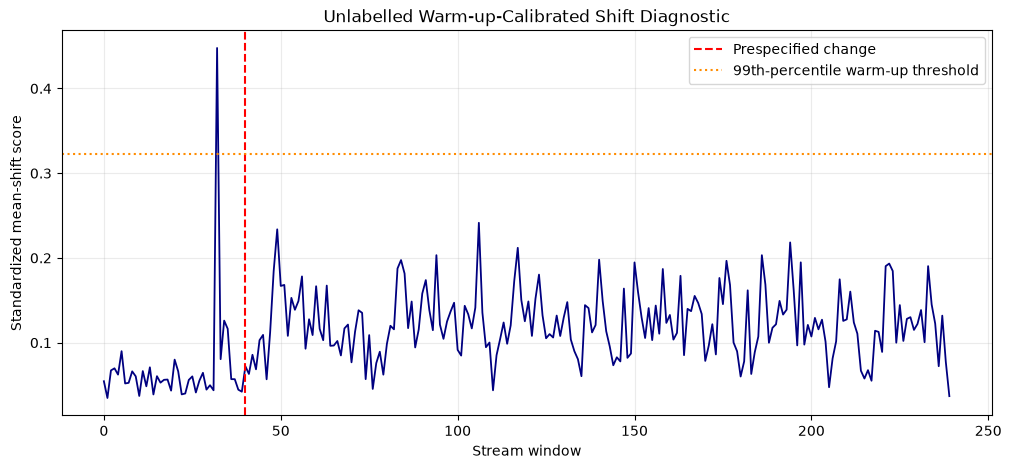

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(
    score_frame["window"],
    score_frame["warmup_reference_score"],
    color="navy",
    linewidth=1.3,
)

plt.axvline(
    change_window,
    color="red",
    linestyle="--",
    label="Prespecified change",
)

threshold_99 = float(pre_scores.quantile(0.99))

plt.axhline(
    threshold_99,
    color="darkorange",
    linestyle=":",
    label="99th-percentile warm-up threshold",
)

plt.xlabel("Stream window")
plt.ylabel("Standardized mean-shift score")
plt.title("Unlabelled Warm-up-Calibrated Shift Diagnostic")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [20]:
# 1. Identify the unusual pre-change windows

In [21]:
top_prechange = (
    score_frame[
        score_frame["phase"] == "pre_change"
    ]
    .nlargest(6, "warmup_reference_score")
)

display(top_prechange)

outlier_records = []

for _, row in top_prechange.iterrows():
    window_index = int(row["window"])
    start = window_index * window_size
    stop = min(start + window_size, len(target_bundle.labels))

    window_labels = target_bundle.labels.iloc[start:stop]
    window_features = target_bundle.features.iloc[start:stop]

    class_counts = window_labels.value_counts().to_dict()

    numeric_matrix = window_features.to_numpy(dtype=float)

    missing_values = int(np.isnan(numeric_matrix).sum())
    infinite_values = int(np.isinf(numeric_matrix).sum())

    times = pd.to_numeric(
        target_bundle.time.iloc[start:stop],
        errors="coerce",
    )

    outlier_records.append({
        "window": window_index,
        "score": row["warmup_reference_score"],
        "benign": class_counts.get("Benign", 0),
        "Exploits": class_counts.get("Exploits", 0),
        "Fuzzers": class_counts.get("Fuzzers", 0),
        "Generic": class_counts.get("Generic", 0),
        "Reconnaissance": class_counts.get("Reconnaissance", 0),
        "DoS": class_counts.get("DoS", 0),
        "missing_values": missing_values,
        "infinite_values": infinite_values,
        "first_time": pd.to_datetime(
            times.min(),
            unit="ms",
            errors="coerce",
        ),
        "last_time": pd.to_datetime(
            times.max(),
            unit="ms",
            errors="coerce",
        ),
    })

display(pd.DataFrame(outlier_records))

,window,warmup_reference_score,phase
32,32,0.447768,pre_change
34,34,0.126032,pre_change
35,35,0.116383,pre_change
5,5,0.089985,pre_change
33,33,0.080557,pre_change
20,20,0.079995,pre_change


,window,score,benign,Exploits,Fuzzers,Generic,Reconnaissance,DoS,missing_values,infinite_values,first_time,last_time
0,32,0.447768,485,3,8,0,3,1,10,26,2015-01-23 00:24:28.783,2015-02-18 00:39:20.335
1,34,0.126032,447,13,20,1,5,14,4,20,2015-02-18 00:42:29.831,2015-02-18 00:45:59.632
2,35,0.116383,448,16,21,1,10,4,2,22,2015-02-18 00:45:59.685,2015-02-18 00:49:18.799
3,5,0.089985,500,0,0,0,0,0,0,14,2015-01-22 22:42:47.471,2015-01-22 22:47:22.883
4,33,0.080557,465,15,7,4,6,3,4,20,2015-02-18 00:39:20.435,2015-02-18 00:42:29.831
5,20,0.079995,500,0,0,0,0,0,0,10,2015-01-22 23:41:11.832,2015-01-22 23:45:15.923


In [22]:
# 2. Compare robust calibration thresholds. This uses only the pre-change scores to construct thresholds.

In [23]:
pre_median = float(pre_scores.median())

mad = float(
    np.median(
        np.abs(pre_scores.to_numpy() - pre_median)
    )
)

robust_scale = 1.4826 * mad

robust_results = []

for multiplier in [3, 4, 5, 6]:
    threshold = pre_median + multiplier * robust_scale

    pre_false = int((pre_scores > threshold).sum())

    post_positions = np.flatnonzero(
        post_scores.to_numpy() > threshold
    )

    robust_results.append({
        "MAD_multiplier": multiplier,
        "threshold": threshold,
        "pre_change_false_triggers": pre_false,
        "post_windows_above_threshold": int(
            (post_scores > threshold).sum()
        ),
        "first_post_change_trigger_delay": (
            int(post_positions[0])
            if len(post_positions)
            else None
        ),
    })

display(pd.DataFrame(robust_results))

print("Pre-change median:", pre_median)
print("Raw MAD:", mad)
print("Scaled MAD:", robust_scale)

,MAD_multiplier,threshold,pre_change_false_triggers,post_windows_above_threshold,first_post_change_trigger_delay
0,3,0.103298,3,135,5
1,4,0.118951,2,100,8
2,5,0.134604,1,69,8
3,6,0.150257,1,42,8


Pre-change median: 0.0563400396819263
Raw MAD: 0.010557652341038365
Scaled MAD: 0.01565277536082348


In [ ]:
# Creation of session-aligned target stream


In [25]:
import gc
import numpy as np
import pandas as pd
import yaml

dataset_file = (
    PROJECT
    / "data"
    / "raw"
    / "NF-UNSW-NB15-v3.csv"
)

print("Loading dataset...")
full = pd.read_csv(dataset_file, low_memory=False)

full["FLOW_START_MILLISECONDS"] = pd.to_numeric(
    full["FLOW_START_MILLISECONDS"],
    errors="raise",
)

full["FLOW_END_MILLISECONDS"] = pd.to_numeric(
    full["FLOW_END_MILLISECONDS"],
    errors="coerce",
)

full["_original_row"] = np.arange(len(full))

print("Sorting chronologically...")
full = full.sort_values(
    [
        "FLOW_START_MILLISECONDS",
        "FLOW_END_MILLISECONDS",
        "_original_row",
    ],
    kind="mergesort",
).reset_index(drop=True)

# Identify the largest temporal gaps
time_differences = full["FLOW_START_MILLISECONDS"].diff()

largest_gap_indices = time_differences.nlargest(10).index

gap_records = []

for row_index in largest_gap_indices:
    previous_time = full.loc[
        row_index - 1,
        "FLOW_START_MILLISECONDS",
    ]

    current_time = full.loc[
        row_index,
        "FLOW_START_MILLISECONDS",
    ]

    gap_records.append({
        "current_row": int(row_index),
        "previous_time": pd.to_datetime(previous_time, unit="ms"),
        "current_time": pd.to_datetime(current_time, unit="ms"),
        "gap_hours": (current_time - previous_time) / 3_600_000,
    })

gap_table = pd.DataFrame(gap_records)

print("Largest timestamp gaps:")
display(gap_table)

Loading dataset...
Sorting chronologically...
Largest timestamp gaps:


,current_row,previous_time,current_time,gap_hours
0,1135352,2015-01-23 00:25:23.759,2015-02-18 00:23:27.658,623.967750
1,691295,2015-01-22 19:21:02.435,2015-01-22 19:35:20.845,0.238447
2,1135624,2015-02-18 00:27:51.323,2015-02-18 00:30:01.335,0.036114
3,1135633,2015-02-18 00:34:21.358,2015-02-18 00:36:31.369,0.036114
4,1135627,2015-02-18 00:30:33.371,2015-02-18 00:32:11.346,0.027215
5,1135621,2015-02-18 00:26:06.298,2015-02-18 00:27:33.798,0.024306
6,1135629,2015-02-18 00:32:11.346,2015-02-18 00:33:33.849,0.022918
7,1135636,2015-02-18 00:36:33.322,2015-02-18 00:37:40.070,0.018541
8,2007954,2015-02-18 09:05:53.857,2015-02-18 09:06:54.687,0.016897
9,155201,2015-01-22 13:24:57.855,2015-01-22 13:25:57.668,0.016615


In [26]:
# Select and verify the largest gap:

In [27]:
session_change_row = int(time_differences.idxmax())

previous_timestamp = full.loc[
    session_change_row - 1,
    "FLOW_START_MILLISECONDS",
]

new_session_timestamp = full.loc[
    session_change_row,
    "FLOW_START_MILLISECONDS",
]

largest_gap_hours = (
    new_session_timestamp - previous_timestamp
) / 3_600_000

print("Session-change row:", session_change_row)
print(
    "Previous session:",
    pd.to_datetime(previous_timestamp, unit="ms"),
)
print(
    "New session:",
    pd.to_datetime(new_session_timestamp, unit="ms"),
)
print("Gap in hours:", largest_gap_hours)

assert largest_gap_hours > 24, (
    "Largest gap is less than 24 hours; inspect the table manually."
)

Session-change row: 1135352
Previous session: 2015-01-23 00:25:23.759000
New session: 2015-02-18 00:23:27.658000
Gap in hours: 623.9677497222223


In [28]:
# Construct a clean target with:

# 20,000 flows before the session gap
# 100,000 flows after the session gap
# Exact change at row 20,000/window 40

In [29]:
SUPPORTED_CLASSES = [
    "Benign",
    "DoS",
    "Exploits",
    "Fuzzers",
    "Generic",
    "Reconnaissance",
]

number_of_rows = len(full)
source_cut = int(np.ceil(0.40 * number_of_rows))

assert source_cut < session_change_row, (
    "Historical source boundary occurs after the session transition."
)

warmup_pool = full.iloc[
    source_cut:session_change_row
].copy()

postchange_pool = full.iloc[
    session_change_row:
].copy()

warmup_pool = warmup_pool[
    warmup_pool["Attack"].isin(SUPPORTED_CLASSES)
].copy()

postchange_pool = postchange_pool[
    postchange_pool["Attack"].isin(SUPPORTED_CLASSES)
].copy()

print("Warm-up pool class distribution:")
display(warmup_pool["Attack"].value_counts().to_frame("Count"))

print("Post-change pool class distribution:")
display(postchange_pool["Attack"].value_counts().to_frame("Count"))

assert len(warmup_pool) >= 20_000
assert len(postchange_pool) >= 100_000

target_warmup = warmup_pool.sample(
    n=20_000,
    random_state=31,
)

target_postchange = postchange_pool.sample(
    n=100_000,
    random_state=32,
)

target_aligned = pd.concat(
    [target_warmup, target_postchange],
    ignore_index=True,
)

target_aligned = target_aligned.sort_values(
    ["FLOW_START_MILLISECONDS", "_original_row"],
    kind="mergesort",
).reset_index(drop=True)

# Verify that the boundary is a real temporal discontinuity
last_warmup_time = target_aligned.loc[
    19_999,
    "FLOW_START_MILLISECONDS",
]

first_postchange_time = target_aligned.loc[
    20_000,
    "FLOW_START_MILLISECONDS",
]

aligned_gap_hours = (
    first_postchange_time - last_warmup_time
) / 3_600_000

print("Aligned warm-up end:",
      pd.to_datetime(last_warmup_time, unit="ms"))

print("Aligned post-change start:",
      pd.to_datetime(first_postchange_time, unit="ms"))

print("Aligned gap hours:", aligned_gap_hours)

assert aligned_gap_hours > 24

target_aligned = target_aligned.drop(
    columns="_original_row"
)

aligned_target_path = (
    PROJECT
    / "data"
    / "processed"
    / "NF-UNSW-NB15-v3-target-session-aligned-pilot.csv"
)

target_aligned.to_csv(
    aligned_target_path,
    index=False,
)

print("Saved:", aligned_target_path)
print("Rows:", len(target_aligned))

Warm-up pool class distribution:


,Count
Attack,
Benign,189182


Post-change pool class distribution:


,Count
Attack,
Benign,1119841
Exploits,37126
Fuzzers,27770
Generic,17246
Reconnaissance,14919
DoS,5356


Aligned warm-up end: 2015-01-23 00:25:23.557000
Aligned post-change start: 2015-02-18 00:23:28.627000
Aligned gap hours: 623.968075
Saved: C:\Users\ASUS\raids-nids\data\processed\NF-UNSW-NB15-v3-target-session-aligned-pilot.csv
Rows: 120000


In [ ]:
# Creation of  dataset configuration

In [31]:
aligned_target_config = {
    "name": "NF-UNSW-NB15-v3-Future-Session-Aligned-Pilot",
    "path": (
        "data/processed/"
        "NF-UNSW-NB15-v3-target-session-aligned-pilot.csv"
    ),
    "label_column": "Attack",
    "extra_label_columns": ["Label"],
    "time_column": "FLOW_START_MILLISECONDS",
    "drop_columns": [
        "FLOW_END_MILLISECONDS",
        "IPV4_SRC_ADDR",
        "IPV4_DST_ADDR",
    ],
    "auto_drop_identifiers": True,
    "sampling": {
        "max_rows": None,
    },
}

aligned_target_config_path = (
    PROJECT
    / "configs"
    / "datasets"
    / "nf_unsw_nb15_v3_target_session_aligned_pilot.yaml"
)

with aligned_target_config_path.open(
    "w",
    encoding="utf-8",
) as file:
    yaml.safe_dump(
        aligned_target_config,
        file,
        sort_keys=False,
    )

print("Created:", aligned_target_config_path)

del full, warmup_pool, postchange_pool
gc.collect()

Created: C:\Users\ASUS\raids-nids\configs\datasets\nf_unsw_nb15_v3_target_session_aligned_pilot.yaml


0

In [ ]:
# 1. Verify the saved pilot

In [32]:
from pathlib import Path
import os
import pandas as pd

PROJECT = Path(r"C:\Users\ASUS\raids-nids")
os.chdir(PROJECT)

TARGET_CSV = (
    PROJECT
    / "data"
    / "processed"
    / "NF-UNSW-NB15-v3-target-session-aligned-pilot.csv"
)

BOUNDARY_ROW = 20_000
WINDOW_SIZE = 500
SUPPORTED = {
    "Benign",
    "DoS",
    "Exploits",
    "Fuzzers",
    "Generic",
    "Reconnaissance",
}

metadata = pd.read_csv(
    TARGET_CSV,
    usecols=["FLOW_START_MILLISECONDS", "Attack"]
)

raw_time = metadata["FLOW_START_MILLISECONDS"]
numeric_time = pd.to_numeric(raw_time, errors="coerce")

if numeric_time.notna().all():
    timestamps = pd.to_datetime(
        numeric_time,
        unit="ms",
        errors="raise"
    )
else:
    timestamps = pd.to_datetime(raw_time, errors="raise")

boundary_gap_hours = (
    timestamps.iloc[BOUNDARY_ROW]
    - timestamps.iloc[BOUNDARY_ROW - 1]
).total_seconds() / 3600

warmup_labels = metadata.iloc[:BOUNDARY_ROW]["Attack"]
post_labels = metadata.iloc[BOUNDARY_ROW:]["Attack"]

assert len(metadata) == 120_000
assert timestamps.is_monotonic_increasing
assert BOUNDARY_ROW % WINDOW_SIZE == 0
assert BOUNDARY_ROW // WINDOW_SIZE == 40
assert boundary_gap_hours > 24
assert set(warmup_labels) == {"Benign"}
assert set(post_labels) == SUPPORTED

def distribution(labels):
    counts = labels.value_counts()
    return pd.DataFrame({
        "count": counts,
        "percent": (100 * counts / counts.sum()).round(4)
    })

phase_distribution = pd.concat(
    {
        "warmup": distribution(warmup_labels),
        "post_change": distribution(post_labels),
    },
    names=["phase", "Attack"]
)

print("Rows:", len(metadata))
print("Windows:", len(metadata) // WINDOW_SIZE)
print("Declared change window:", BOUNDARY_ROW // WINDOW_SIZE)
print("Boundary gap hours:", boundary_gap_hours)
display(phase_distribution)

Rows: 120000
Windows: 240
Declared change window: 40
Boundary gap hours: 623.968075


count  percent
phase       Attack                        
warmup      Benign          20000  100.000
post_change Benign          91612   91.612
            Exploits         3015    3.015
            Fuzzers          2319    2.319
            Generic          1423    1.423
            Reconnaissance   1219    1.219
            DoS               412    0.412

In [ ]:
# 2. Create session-aligned static configurations

In [35]:
import copy
from pathlib import Path

from raids_nids.config import load_yaml, dump_yaml

NEW_RUN_NAME = "E02_E05_UNSW_session_aligned_pilot_v012"

NEW_TARGET_CONFIG = (
    "configs/datasets/"
    "nf_unsw_nb15_v3_target_session_aligned_pilot.yaml"
)

METHOD_FILES = {
    "prototype_static_closed":
        "unsw_session_aligned_prototype_static_v012.yaml",
    "logistic_closed":
        "unsw_session_aligned_logistic_static_v012.yaml",
    "random_forest_closed":
        "unsw_session_aligned_random_forest_static_v012.yaml",
}

runs_root = PROJECT / "results" / "runs"
experiment_root = PROJECT / "configs" / "experiments"
experiment_root.mkdir(parents=True, exist_ok=True)

# Find all previous resolved configurations by method name.
candidates = {method: [] for method in METHOD_FILES}

for resolved_path in runs_root.rglob("resolved_config.yaml"):
    try:
        candidate = load_yaml(resolved_path)
    except Exception:
        continue

    method_name = candidate.get("method", {}).get("name")

    if method_name not in METHOD_FILES:
        continue

    source_text = str(candidate.get("source_dataset", "")).lower()
    target_text = str(candidate.get("target_dataset", "")).lower()
    adaptation_enabled = bool(
        candidate.get("adaptation", {}).get("enabled", False)
    )

    # Retain only static NF-UNSW-NB15-v3 experiments.
    if (
        "nf_unsw_nb15_v3" in source_text
        and "nf_unsw_nb15_v3" in target_text
        and not adaptation_enabled
    ):
        candidates[method_name].append(
            (resolved_path, candidate)
        )

# Show everything that was found.
candidate_rows = []

for method_name, items in candidates.items():
    for path, config in items:
        candidate_rows.append({
            "method": method_name,
            "run_name": config.get("name"),
            "target_config": config.get("target_dataset"),
            "resolved_config": str(path),
        })

candidate_table = pd.DataFrame(candidate_rows)

if len(candidate_table):
    display(
        candidate_table.sort_values(
            ["method", "run_name"]
        )
    )

missing = [
    method
    for method, items in candidates.items()
    if not items
]

if missing:
    raise FileNotFoundError(
        "No static NF-UNSW resolved configuration was found for: "
        f"{missing}"
    )

# Prefer the old non-session-aligned pilot, then the newest candidate.
def candidate_rank(item):
    path, config = item
    target = str(config.get("target_dataset", "")).lower()
    run_name = str(config.get("name", "")).lower()

    is_old_target = (
        "target_pilot" in target
        and "session_aligned" not in target
    )

    is_temporal_pilot = (
        "temporal" in run_name
        and "session_aligned" not in run_name
    )

    return (
        int(is_old_target),
        int(is_temporal_pilot),
        path.stat().st_mtime,
    )

selected_configs = {
    method: max(items, key=candidate_rank)
    for method, items in candidates.items()
}

aligned_config_paths = {}

for method_name, filename in METHOD_FILES.items():
    source_path, old_config = selected_configs[method_name]
    config = copy.deepcopy(old_config)

    config["name"] = NEW_RUN_NAME
    config["seed"] = 11
    config["target_dataset"] = NEW_TARGET_CONFIG
    config["output_root"] = "results/runs"

    config.setdefault("scenario", {})
    config["scenario"]["name"] = (
        "supported_6class_capture_session_and_prevalence_shift"
    )
    config["scenario"]["holdout_labels"] = []

    config.setdefault("stream", {})
    config["stream"]["mode"] = "chronological"
    config["stream"]["window_size"] = 500
    config["stream"]["true_change_window"] = 40
    config["stream"].pop("known_prefix_fraction", None)

    config.setdefault("method", {})
    config["method"]["name"] = method_name
    config["method"]["open_set"] = False

    config.setdefault("adaptation", {})
    config["adaptation"]["enabled"] = False
    config["adaptation"]["label_budget_fraction"] = 0.0

    output_path = experiment_root / filename
    dump_yaml(config, output_path)
    aligned_config_paths[method_name] = output_path

    print(f"\n{method_name}")
    print("Selected previous configuration:")
    print(source_path)
    print("Created aligned configuration:")
    print(output_path)

print("\nAll three configurations created successfully.")

,method,run_name,target_config,resolved_config
2,logistic_closed,E02_E05_UNSW_logistic_v012,configs/datasets/nf_unsw_nb15_v3_target_pilot....,C:\Users\ASUS\raids-nids\results\runs\E02_E05_...
1,prototype_static_closed,E02_E05_UNSW_temporal_pilot,configs/datasets/nf_unsw_nb15_v3_target_pilot....,C:\Users\ASUS\raids-nids\results\runs\E02_E05_...
0,prototype_static_closed,E02_E05_UNSW_temporal_pilot_v012,configs/datasets/nf_unsw_nb15_v3_target_pilot....,C:\Users\ASUS\raids-nids\results\runs\E02_E05_...
3,random_forest_closed,E02_E05_UNSW_random_forest_v012,configs/datasets/nf_unsw_nb15_v3_target_pilot....,C:\Users\ASUS\raids-nids\results\runs\E02_E05_...



prototype_static_closed
Selected previous configuration:
C:\Users\ASUS\raids-nids\results\runs\E02_E05_UNSW_temporal_pilot_v012__NF-UNSW-NB15-v3-Historical-Pilot-to-NF-UNSW-NB15-v3-Future-Pilot__supported_6class_temporal_shift__prototype_static_closed__seed11\resolved_config.yaml
Created aligned configuration:
C:\Users\ASUS\raids-nids\configs\experiments\unsw_session_aligned_prototype_static_v012.yaml

logistic_closed
Selected previous configuration:
C:\Users\ASUS\raids-nids\results\runs\E02_E05_UNSW_logistic_v012__NF-UNSW-NB15-v3-Historical-Pilot-to-NF-UNSW-NB15-v3-Future-Pilot__supported_6class_temporal_shift__logistic_closed__seed11\resolved_config.yaml
Created aligned configuration:
C:\Users\ASUS\raids-nids\configs\experiments\unsw_session_aligned_logistic_static_v012.yaml

random_forest_closed
Selected previous configuration:
C:\Users\ASUS\raids-nids\results\runs\E02_E05_UNSW_random_forest_v012__NF-UNSW-NB15-v3-Historical-Pilot-to-NF-UNSW-NB15-v3-Future-Pilot__supported_6class_te

In [ ]:
# 3. three corrected baselines

In [37]:
import pandas as pd

from raids_nids.runner import run_experiment

aligned_summaries = []

for method_name, config_path in aligned_config_paths.items():
    print(f"\nRunning {method_name}...")
    summary = run_experiment(config_path)
    aligned_summaries.append(summary)
    print("Completed.")

for summary in aligned_summaries:
    assert summary["target_rows"] == 120_000
    assert summary["window_count"] == 240
    assert summary["true_change_window"] == 40
    assert summary["novel_target_classes"] == []
    assert summary["labels_queried"] == 0
    assert summary["integrity_checks"]["label_budget_respected"]
    assert summary["integrity_checks"]["predictions_scored_before_updates"]
    assert summary["integrity_checks"]["preprocessing_fit_on_source_only"]

aligned_results = pd.DataFrame(aligned_summaries)

result_columns = [
    "method",
    "source_reference_macro_f1",
    "global_known_macro_f1",
    "global_known_balanced_accuracy",
    "global_known_mcc",
    "mean_known_macro_f1",
    "pre_change_reference",
    "initial_degradation",
    "primary_normalized_recovery_area",
    "recovery_time_windows",
    "fit_seconds",
    "prediction_seconds",
]

display(
    aligned_results[result_columns]
    .sort_values("global_known_macro_f1", ascending=False)
)

integrity_table = pd.DataFrame([
    {
        "method": row["method"],
        **row["integrity_checks"]
    }
    for row in aligned_summaries
])

display(integrity_table)


Running prototype_static_closed...
Completed.

Running logistic_closed...


C:\Users\ASUS\anaconda3\envs\raids-nids\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Completed.

Running random_forest_closed...
Completed.


,method,source_reference_macro_f1,global_known_macro_f1,global_known_balanced_accuracy,global_known_mcc,mean_known_macro_f1,pre_change_reference,initial_degradation,primary_normalized_recovery_area,recovery_time_windows,fit_seconds,prediction_seconds
2,random_forest_closed,0.743619,0.725356,0.711297,0.863482,0.782147,1.000000,0.227824,0.738576,4,6.920047,36.786131
1,logistic_closed,0.548276,0.533897,0.604073,0.685427,0.626118,0.999825,0.538658,0.551472,4,37.046280,3.743798
0,prototype_static_closed,0.340275,0.314826,0.362588,0.466123,0.457173,0.989192,0.525560,0.354572,4,1.126076,3.167358


,method,initial_model_saw_novel_target_class_names,label_budget_respected,predictions_scored_before_updates,preprocessing_fit_on_source_only
0,prototype_static_closed,False,True,True,True
1,logistic_closed,False,True,True,True
2,random_forest_closed,False,True,True,True


In [38]:
# 1. Logistic convergence rerun

In [39]:
import copy
import warnings
import joblib
import numpy as np
import pandas as pd

from sklearn.exceptions import ConvergenceWarning
from raids_nids.config import load_yaml, dump_yaml
from raids_nids.runner import run_experiment

base_logistic_config = (
    PROJECT
    / "configs"
    / "experiments"
    / "unsw_session_aligned_logistic_static_v012.yaml"
)

converged_config_path = (
    PROJECT
    / "configs"
    / "experiments"
    / "unsw_session_aligned_logistic_5000_v012.yaml"
)

logistic_config = copy.deepcopy(
    load_yaml(base_logistic_config)
)

logistic_config["name"] = (
    "E02_E05_UNSW_session_aligned_logistic_5000_v012"
)

logistic_config.setdefault("method", {})
logistic_config["method"]["name"] = "logistic_closed"
logistic_config["method"]["type"] = "logistic"
logistic_config["method"]["open_set"] = False

logistic_config["method"].setdefault("parameters", {})
logistic_config["method"]["parameters"]["max_iter"] = 5000

dump_yaml(logistic_config, converged_config_path)

with warnings.catch_warnings(record=True) as recorded_warnings:
    warnings.simplefilter("always", ConvergenceWarning)

    logistic_5000_summary = run_experiment(
        converged_config_path
    )

convergence_warnings = [
    warning
    for warning in recorded_warnings
    if issubclass(warning.category, ConvergenceWarning)
]

print("Convergence warnings:", len(convergence_warnings))

Convergence warnings: 0


In [ ]:
# Location of saved model and verify its actual iteration count.

In [41]:
matching_runs = []

for resolved_path in (
    PROJECT / "results" / "runs"
).rglob("resolved_config.yaml"):

    config = load_yaml(resolved_path)

    if (
        config.get("name")
        == "E02_E05_UNSW_session_aligned_logistic_5000_v012"
        and config.get("method", {}).get("name")
        == "logistic_closed"
    ):
        matching_runs.append(resolved_path.parent)

if not matching_runs:
    raise FileNotFoundError(
        "Could not find the 5000-iteration logistic run."
    )

logistic_run_dir = max(
    matching_runs,
    key=lambda path: path.stat().st_mtime
)

logistic_model = joblib.load(
    logistic_run_dir / "model.joblib"
)

iterations_used = logistic_model.estimator.n_iter_
maximum_iterations = logistic_model.estimator.max_iter

print("Iterations used:", iterations_used)
print("Maximum allowed:", maximum_iterations)
print(
    "Converged:",
    len(convergence_warnings) == 0
    and np.all(iterations_used < maximum_iterations)
)

display(pd.DataFrame([logistic_5000_summary])[[
    "method",
    "source_reference_macro_f1",
    "global_known_macro_f1",
    "global_known_balanced_accuracy",
    "global_known_mcc",
    "mean_known_macro_f1",
    "pre_change_reference",
    "initial_degradation",
    "primary_normalized_recovery_area",
    "recovery_time_windows",
    "fit_seconds",
    "prediction_seconds",
]])

Iterations used: [1334]
Maximum allowed: 5000
Converged: True


,method,source_reference_macro_f1,global_known_macro_f1,global_known_balanced_accuracy,global_known_mcc,mean_known_macro_f1,pre_change_reference,initial_degradation,primary_normalized_recovery_area,recovery_time_windows,fit_seconds,prediction_seconds
0,logistic_closed,0.548714,0.534297,0.604885,0.685359,0.626315,0.999825,0.54136,0.551707,4,50.755142,4.801183


In [ ]:
# 2. Investigate the apparent four-window recovery

# This checks whether windows 44–45 are simply benign-dominated.

In [42]:
TARGET_CSV = (
    PROJECT
    / "data"
    / "processed"
    / "NF-UNSW-NB15-v3-target-session-aligned-pilot.csv"
)

WINDOW_SIZE = 500
CHANGE_WINDOW = 40

target_labels = pd.read_csv(
    TARGET_CSV,
    usecols=["Attack"]
)

target_labels["window"] = (
    np.arange(len(target_labels)) // WINDOW_SIZE
)

class_counts = pd.crosstab(
    target_labels["window"],
    target_labels["Attack"]
)

for label in [
    "Benign",
    "DoS",
    "Exploits",
    "Fuzzers",
    "Generic",
    "Reconnaissance",
]:
    if label not in class_counts:
        class_counts[label] = 0

class_counts["attack_rows"] = (
    class_counts.drop(columns=["Benign"]).sum(axis=1)
)

class_counts["attack_percent"] = (
    100 * class_counts["attack_rows"] / WINDOW_SIZE
)

class_counts["classes_present"] = (
    class_counts[
        [
            "Benign",
            "DoS",
            "Exploits",
            "Fuzzers",
            "Generic",
            "Reconnaissance",
        ]
    ].gt(0).sum(axis=1)
)

def find_run_directory(run_name, method_name):
    matches = []

    for resolved_path in (
        PROJECT / "results" / "runs"
    ).rglob("resolved_config.yaml"):

        config = load_yaml(resolved_path)

        if (
            config.get("name") == run_name
            and config.get("method", {}).get("name")
            == method_name
        ):
            matches.append(resolved_path.parent)

    if not matches:
        raise FileNotFoundError(
            f"No run found for {method_name}"
        )

    return max(
        matches,
        key=lambda path: path.stat().st_mtime
    )

trace = class_counts.reset_index()

for method_name in [
    "prototype_static_closed",
    "logistic_closed",
    "random_forest_closed",
]:
    run_dir = find_run_directory(
        "E02_E05_UNSW_session_aligned_pilot_v012",
        method_name
    )

    windows = pd.read_csv(run_dir / "windows.csv")

    trace = trace.merge(
        windows[["window", "known_macro_f1"]].rename(
            columns={
                "known_macro_f1": f"{method_name}_macro_f1"
            }
        ),
        on="window",
        how="left",
    )

display(
    trace.loc[
        trace["window"].between(38, 52),
        [
            "window",
            "Benign",
            "DoS",
            "Exploits",
            "Fuzzers",
            "Generic",
            "Reconnaissance",
            "attack_percent",
            "classes_present",
            "prototype_static_closed_macro_f1",
            "logistic_closed_macro_f1",
            "random_forest_closed_macro_f1",
        ],
    ]
)

,window,Benign,DoS,Exploits,Fuzzers,Generic,Reconnaissance,attack_percent,classes_present,prototype_static_closed_macro_f1,logistic_closed_macro_f1,random_forest_closed_macro_f1
38,38,500,0,0,0,0,0,0.0,1,0.998999,1.000000,1.000000
39,39,500,0,0,0,0,0,0.0,1,0.987854,1.000000,1.000000
40,40,475,1,8,11,1,4,5.0,6,0.463632,0.461167,0.772176
41,41,462,7,15,8,5,3,7.6,6,0.263887,0.455634,0.642806
42,42,447,13,8,27,0,5,10.6,5,0.415874,0.591889,0.724062
43,43,472,1,4,19,0,4,5.6,5,0.356080,0.482495,0.495610
44,44,500,0,0,0,0,0,0.0,1,0.994975,1.000000,1.000000
45,45,500,0,0,0,0,0,0.0,1,0.982706,0.998999,0.998999
46,46,500,0,0,0,0,0,0.0,1,0.986829,1.000000,1.000000
47,47,494,2,4,0,0,0,1.2,3,0.326489,0.333333,0.851852


In [ ]:
# test recovery using 5,000-row evaluation blocks and three-block persistence.reduces class-support instability.

# Creation of 5,000-row evaluation configurations

In [44]:
import copy
from raids_nids.config import load_yaml, dump_yaml

BASE_CONFIGS = {
    "prototype_static_closed": (
        PROJECT / "configs" / "experiments"
        / "unsw_session_aligned_prototype_static_v012.yaml"
    ),
    "logistic_closed": (
        PROJECT / "configs" / "experiments"
        / "unsw_session_aligned_logistic_5000_v012.yaml"
    ),
    "random_forest_closed": (
        PROJECT / "configs" / "experiments"
        / "unsw_session_aligned_random_forest_static_v012.yaml"
    ),
}

OUTPUT_FILES = {
    "prototype_static_closed":
        "unsw_session_aligned_prototype_eval5000_v012.yaml",
    "logistic_closed":
        "unsw_session_aligned_logistic_eval5000_v012.yaml",
    "random_forest_closed":
        "unsw_session_aligned_random_forest_eval5000_v012.yaml",
}

EVENT_ROW = 20_000
EVALUATION_BLOCK_SIZE = 5_000

assert EVENT_ROW % EVALUATION_BLOCK_SIZE == 0
CHANGE_BLOCK = EVENT_ROW // EVALUATION_BLOCK_SIZE

eval5000_config_paths = {}

for method_name, base_path in BASE_CONFIGS.items():
    config = copy.deepcopy(load_yaml(base_path))

    config["name"] = (
        "E02_E05_UNSW_session_aligned_eval5000_v012"
    )

    config["scenario"]["name"] = (
        "supported_6class_capture_session_and_prevalence_shift"
    )

    config["stream"]["mode"] = "chronological"
    config["stream"]["window_size"] = EVALUATION_BLOCK_SIZE
    config["stream"]["true_change_window"] = CHANGE_BLOCK

    config.setdefault("metrics", {})
    config["metrics"]["recovery_fraction"] = 0.95

    # Three consecutive blocks = 15,000 observations.
    config["metrics"]["recovery_patience_windows"] = 3

    config["method"]["open_set"] = False
    config["adaptation"]["enabled"] = False
    config["adaptation"]["label_budget_fraction"] = 0.0

    if method_name == "logistic_closed":
        config["method"].setdefault("parameters", {})
        config["method"]["parameters"]["max_iter"] = 5000

    output_path = (
        PROJECT
        / "configs"
        / "experiments"
        / OUTPUT_FILES[method_name]
    )

    dump_yaml(config, output_path)
    eval5000_config_paths[method_name] = output_path

    print("Created:", output_path)

print("Change block:", CHANGE_BLOCK)
print("Total evaluation blocks:", 120_000 // EVALUATION_BLOCK_SIZE)

Created: C:\Users\ASUS\raids-nids\configs\experiments\unsw_session_aligned_prototype_eval5000_v012.yaml
Created: C:\Users\ASUS\raids-nids\configs\experiments\unsw_session_aligned_logistic_eval5000_v012.yaml
Created: C:\Users\ASUS\raids-nids\configs\experiments\unsw_session_aligned_random_forest_eval5000_v012.yaml
Change block: 4
Total evaluation blocks: 24


In [ ]:
# 5,000-row baselines

In [45]:
import warnings
import pandas as pd

from sklearn.exceptions import ConvergenceWarning
from raids_nids.runner import run_experiment

eval5000_summaries = []
convergence_warning_count = 0

for method_name, config_path in eval5000_config_paths.items():
    print(f"\nRunning {method_name}...")

    with warnings.catch_warnings(record=True) as captured:
        warnings.simplefilter("always", ConvergenceWarning)
        summary = run_experiment(config_path)

    convergence_warning_count += sum(
        issubclass(item.category, ConvergenceWarning)
        for item in captured
    )

    eval5000_summaries.append(summary)
    print("Completed.")

eval5000_results = pd.DataFrame(eval5000_summaries)

assert (eval5000_results["target_rows"] == 120_000).all()
assert (eval5000_results["window_count"] == 24).all()
assert (eval5000_results["true_change_window"] == 4).all()

print(
    "Total convergence warnings:",
    convergence_warning_count
)

display(
    eval5000_results[[
        "method",
        "source_reference_macro_f1",
        "global_known_macro_f1",
        "global_known_balanced_accuracy",
        "global_known_mcc",
        "mean_known_macro_f1",
        "pre_change_reference",
        "initial_degradation",
        "primary_normalized_recovery_area",
        "recovery_time_windows",
        "fit_seconds",
        "prediction_seconds",
    ]].sort_values(
        "global_known_macro_f1",
        ascending=False
    )
)


Running prototype_static_closed...
Completed.

Running logistic_closed...
Completed.

Running random_forest_closed...
Completed.
Total convergence warnings: 0


,method,source_reference_macro_f1,global_known_macro_f1,global_known_balanced_accuracy,global_known_mcc,mean_known_macro_f1,pre_change_reference,initial_degradation,primary_normalized_recovery_area,recovery_time_windows,fit_seconds,prediction_seconds
2,random_forest_closed,0.743619,0.725356,0.711297,0.863482,0.764654,1.000000,0.312351,0.717585,None,6.401859,4.894388
1,logistic_closed,0.548714,0.534297,0.604885,0.685359,0.601427,0.999825,0.524504,0.521838,None,51.872850,0.688732
0,prototype_static_closed,0.340275,0.314826,0.362588,0.466123,0.429856,0.989227,0.671080,0.321445,None,1.188787,0.743708


In [ ]:
# Verification of class support in each 5,000-row block

In [46]:
target_labels = pd.read_csv(
    TARGET_CSV,
    usecols=["Attack"]
)

target_labels["evaluation_block"] = (
    np.arange(len(target_labels))
    // EVALUATION_BLOCK_SIZE
)

block_counts = pd.crosstab(
    target_labels["evaluation_block"],
    target_labels["Attack"]
)

supported_order = [
    "Benign",
    "DoS",
    "Exploits",
    "Fuzzers",
    "Generic",
    "Reconnaissance",
]

for label in supported_order:
    if label not in block_counts:
        block_counts[label] = 0

block_counts["attack_rows"] = (
    block_counts.drop(columns=["Benign"]).sum(axis=1)
)

block_counts["attack_percent"] = (
    100
    * block_counts["attack_rows"]
    / EVALUATION_BLOCK_SIZE
)

block_counts["classes_present"] = (
    block_counts[supported_order]
    .gt(0)
    .sum(axis=1)
)

display(
    block_counts.loc[
        2:10,
        supported_order
        + [
            "attack_rows",
            "attack_percent",
            "classes_present",
        ]
    ]
)

Attack,Benign,DoS,Exploits,Fuzzers,Generic,Reconnaissance,attack_rows,attack_percent,classes_present
evaluation_block,,,,,,,,,
2,5000,0,0,0,0,0,0,0.00,1
3,5000,0,0,0,0,0,0,0.00,1
4,4796,25,69,78,8,24,204,4.08,6
5,4563,12,150,108,87,80,437,8.74,6
6,4472,20,160,141,147,60,528,10.56,6
7,4542,18,183,163,25,69,458,9.16,6
8,4663,12,134,111,34,46,337,6.74,6
9,4532,26,141,92,136,73,468,9.36,6
10,4579,23,150,131,61,56,421,8.42,6
